Initial B-tree:


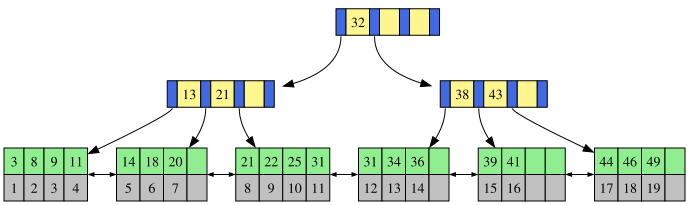

After inserting 50:


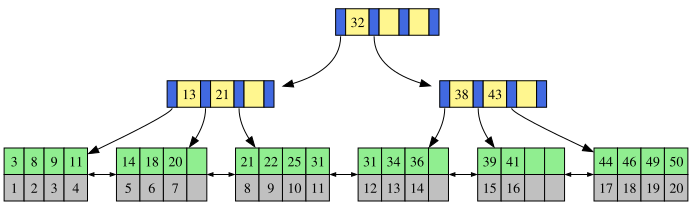

After inserting 53:


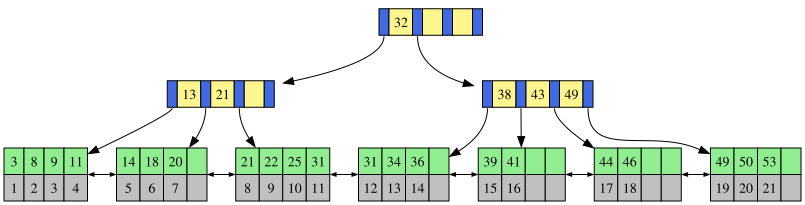

After inserting 55:


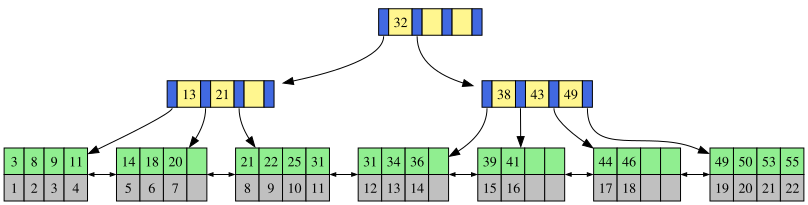

After inserting 58:


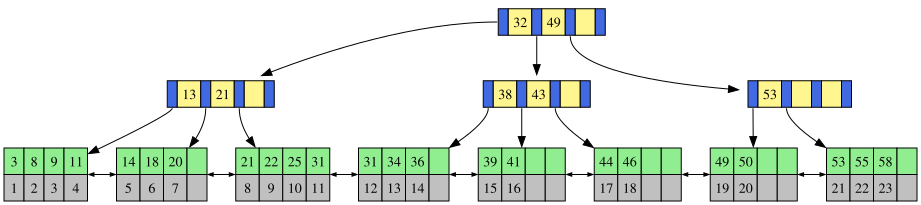

In [1]:
from system.indexes.btree import BPlusTree

# create leaves
leaf_1 = BPlusTree.Leaf(4, [3, 8, 9, 11], [1, 2, 3, 4])
leaf_2 = BPlusTree.Leaf(4, [14, 18, 20], [5, 6, 7])
leaf_3 = BPlusTree.Leaf(4, [21, 22, 25, 31], [8, 9, 10, 11])
leaf_4 = BPlusTree.Leaf(4, [31, 34, 36], [12, 13, 14])
leaf_5 = BPlusTree.Leaf(4, [39, 41], [15, 16])
leaf_6 = BPlusTree.Leaf(4, [44, 46, 49], [17, 18, 19])

# connect leaves
leaf_1.next = leaf_2
leaf_2.previous = leaf_1
leaf_2.next = leaf_3
leaf_3.previous = leaf_2
leaf_3.next = leaf_4
leaf_4.previous = leaf_3
leaf_4.next = leaf_5
leaf_5.previous = leaf_4
leaf_5.next = leaf_6
leaf_6.previous = leaf_5

# create inner nodes
inner_1 = BPlusTree.Inner(3, [13, 21], [leaf_1, leaf_2, leaf_3])
inner_2 = BPlusTree.Inner(3, [38, 43], [leaf_4, leaf_5, leaf_6])

# create root node
root = BPlusTree.Inner(3, [32], [inner_1, inner_2])

# create B-tree
bplustree = BPlusTree[int, int](3, 4)
bplustree.root = root
print("Initial B-tree:")
bplustree.show()

# insert values
bplustree.put(50, 20)
print("After inserting 50:")
bplustree.show()
bplustree.put(53, 21)
print("After inserting 53:")
bplustree.show()
bplustree.put(55, 22)
print("After inserting 55:")
bplustree.show()
bplustree.put(58, 23)
print("After inserting 58:")
bplustree.show()

**Using a B-tree for partitioning:**

The inner nodes of a b-tree are a model of the underlying data. Let's see why:

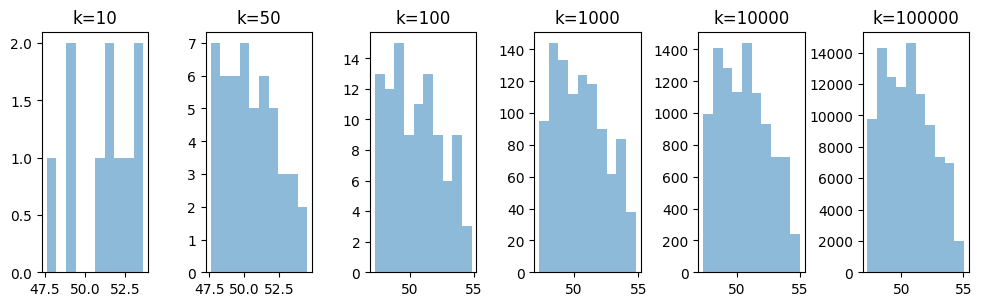

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random as rnd


# Load latitude/longitude data from disk
loaded_data = np.fromfile("latitude_longitude.bin", dtype=np.float32).reshape(-1, 2)

# remove duplicates as our b-tree cannot handle duplicates so far:
# correct would be to keep duplicates for counting, but this is not necessary to prove the point here
data = set()
for latitude, longitude in loaded_data:
    data.add(latitude)

# We need a sample of the data, i.e. a subset that has similar statistical properties:
# (1.) let's shuffle the input:
data = list(data)
rnd.shuffle(data)

# (2.) And show histograms of varying granularity
fig, axs = plt.subplots(1, 6, figsize=(10, 3))
fig.tight_layout()

for idx, k in enumerate([10, 50, 100, 1000, 10000, 100000]):
    # take the first k elements as a sample:
    sample = data[:k]

    # plot the histogram:
    axs[idx].title.set_text(f"k={k}")
    axs[idx].hist(sample, bins=10, alpha=0.5)
    axs[idx].plot()

The bigger the sample the less the change in the shape of the histogram.

Now, we will show how to use a b-tree to create an equi-depth partitioning:

In [3]:
# create a b-tree with a decent sample size:
# we use small inners and big leaves, the goal here is to obtain a small "inner tree" (all nodes except the leaves)
bplustree = BPlusTree[int, int](5, 2000)
sample = sample[:10000]

# insert the sample data
for el in sample:
    bplustree.put(el, el)

In [4]:
# this can be slow:
# bplustree.show()

In [5]:
# now we replace the leaf level by CountingLeaves
# those are leaves that do not store the data but simply count the number of put calls
bplustree.convert_to_counting_leaf_tree()

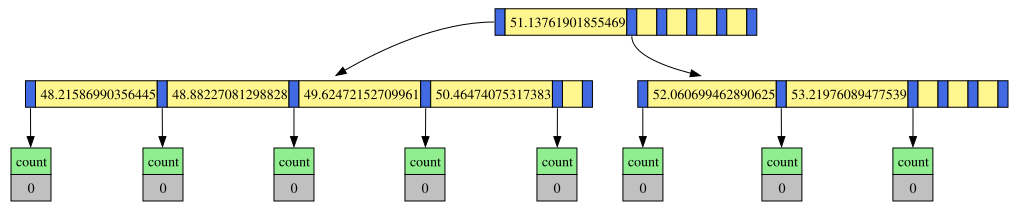

In [6]:
bplustree.show()

All leaves were replaced: the counts are all set to 0.

In [7]:
# Now, let's insert all data into this counting tree:
for el in data:
    bplustree.put(el, el)

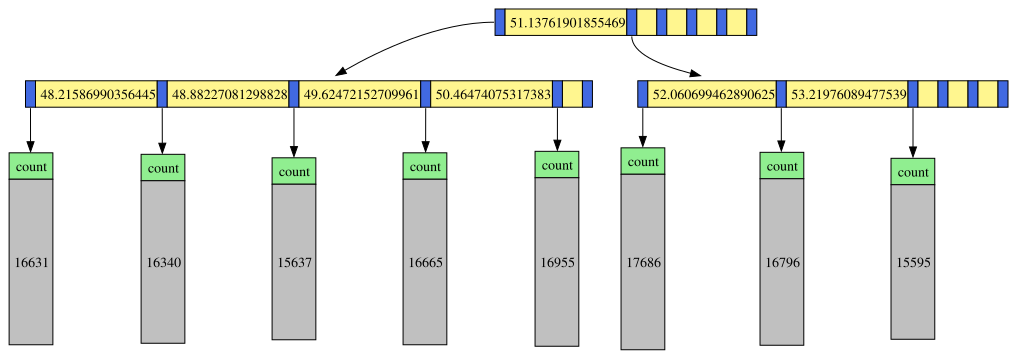

In [8]:
# Here is the result
bplustree.show()

We created an equi-depth partitioning!